# 数据读取

In [25]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
from pathlib import Path

sales_df = pd.read_csv('sales.csv', header = 0, index_col = 0)
train_df = pd.read_csv('stfore_train.csv', header = 0)
test_df = pd.read_csv('stfore_test.csv', header = 0)

restocks_df = pd.read_csv('restocks.csv', header = 0)
price_discount_df = pd.read_csv('price_discount_series.csv', header = 0)

weather_df = pd.read_csv('vis2_weather_data.csv', header = 0)
gtrends_df = pd.read_csv('vis2_gtrends_data.csv', header = 0)

BASE_PIC_DIR = Path("/Users/xunannan/Desktop/课题/数据/images")
emb_df = sales_df[['external_code', 'image_path']].drop_duplicates().reset_index(drop=True)

class VisuelleDataset(Dataset):
    def __init__(self, img_paths, root, transform):
        self.img_paths = img_paths
        self.root = root
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # 拼接完整路径并读取
        path = self.root / self.img_paths[idx]
        try:
            img = Image.open(path).convert('RGB')
            return self.transform(img), self.img_paths[idx]
        except:
            return torch.zeros(3, 224, 224), "ERROR"

def run_feature_extraction(emb_df, pic_dir):
    # 自动识别 MacBook 的 MPS 加速
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"🌟 使用设备: {device}")

    # 加载预训练 ResNet50 并切掉最后一层分类头
    base_model = models.resnet50(weights='IMAGENET1K_V2')
    extractor = nn.Sequential(*list(base_model.children())[:-1]).to(device)
    extractor.eval()

    # 预处理流水线
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 准备 DataLoader (多线程读取)
    unique_imgs = emb_df['image_path'].unique()
    ds = VisuelleDataset(unique_imgs, pic_dir, transform)
    loader = DataLoader(ds, batch_size=32, num_workers=0)

    features = {}
    with torch.no_grad():
        for imgs, paths in tqdm(loader, desc="提取图片特征"):
            imgs = imgs.to(device)
            # 得到特征并压扁成一维向量
            emb = extractor(imgs).squeeze().cpu().numpy()
            
            for p, e in zip(paths, emb):
                if p != "ERROR":
                    features[p] = e

    # 将特征映射回原始 DataFrame
    emb_df['image_emb'] = emb_df['image_path'].map(features)
    return emb_df

# ================= 执行 =================
if __name__ == "__main__":
    emb_df = run_feature_extraction(emb_df, BASE_PIC_DIR)
    emb_df = emb_df.drop(columns=['image_path'])
    print(f"✅ 处理完成！特征维度: {emb_df['image_emb'].iloc[0].shape}")

🌟 使用设备: mps


提取图片特征: 100%|██████████| 168/168 [01:41<00:00,  1.66it/s]

✅ 处理完成！特征维度: (2048,)


In [26]:
import numpy as np
from sklearn.cluster import KMeans

# 在提取图片后立即处理缺失值
emb_df_clean = emb_df.copy()
emb_df_clean['image_emb'] = emb_df['image_emb'].apply(
    lambda x: x if isinstance(x, np.ndarray) else np.zeros(2048, dtype=np.float32)
)

# 不计算归一化的，而是绝对销量
# test_df = sales_df.merge(test_df[['external_code', 'retail', 'release_date']], on=['external_code', 'retail', 'release_date'], how='inner')
# train_df = sales_df.merge(train_df[['external_code', 'retail', 'release_date']], on=['external_code', 'retail', 'release_date'], how='inner')

# 补充价格信息
test_price_df = test_df.merge(
    price_discount_df[['external_code', 'retail', 'price']], 
    on=['external_code', 'retail'], 
    how='left'
)

train_price_df = train_df.merge(
    price_discount_df[['external_code', 'retail', 'price']], 
    on=['external_code', 'retail'], 
    how='left'
)

# 计算每个产品所有店铺的初始库存
restock_week = restocks_df.copy()
restock_week['relative_week'] = restock_week.groupby(['external_code', 'retail']).cumcount() + 1
restock_first = restock_week[restock_week['relative_week'] == 1]

# 补充初始库存信息
test_stock_df = test_price_df.merge(
    restock_first[['external_code', 'retail', 'qty']],
    on = ['external_code', 'retail'],
    how = 'left'
)

train_stock_df = train_price_df.merge(
    restock_first[['external_code', 'retail', 'qty']],
    on = ['external_code', 'retail'],
    how = 'left'
)

# 补充折扣空缺值
price_discount_df['0'] = price_discount_df['0'].fillna(price_discount_df['0'].mode()[0])

# 把销量列合并为列表
weeks = [str(i) for i in range(12)]
def bundle_features(df, cols, new_col):
    df[new_col] = df[cols].values.tolist()
    return df
test_df = bundle_features(test_stock_df, weeks, "curve")
train_df = bundle_features(train_stock_df, weeks, "curve")
price_discount_df = bundle_features(price_discount_df, weeks, "discount_curve")

# 合并销量、价格折扣和图片向量表格
def merge_datas(df):
    df = (
        df
        .merge(emb_df_clean, on = 'external_code', how = 'left')
        .merge(price_discount_df[['external_code', 'retail', 'discount_curve']], 
                on=['external_code', 'retail'], how='left')
    )
    final_cols = ['external_code', 'retail', 'restock', 'curve', 'category', 'color', 'fabric', 'image_emb', 'price', 'discount_curve', 'season', 'release_date']
    return df[final_cols]
train = merge_datas(train_df)
test = merge_datas(test_df)


# 提取价格数据并变形
X_pri = train[['price']].values

# 聚类成 4 类（例如：特价、常规、高端、极高）
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
train['pri_cluster'] = kmeans.fit_predict(X_pri)

# 聚类后的标签 0,1,2,3 顺序是随机的，可以根据类别的均值重新排序使其具有单调性
cluster_centers = train.groupby('pri_cluster')['price'].mean().sort_values().index
pri_mapping = {old: new for new, old in enumerate(cluster_centers)}
train['pri_cluster_asc'] = train['pri_cluster'].map(pri_mapping)
train = train.drop(columns = ['pri_cluster'])

# 使用 train 训练好的 kmeans 模型对 test 的价格进行预测
X_test_pri = test[['price']].values
test['pri_cluster'] = kmeans.predict(X_test_pri)

# 复用刚才 train 产生的 mapping 字典
test['pri_cluster_asc'] = test['pri_cluster'].map(pri_mapping)
test = test.drop(columns = ['pri_cluster'])

In [27]:
print(test.head(3))

   external_code  retail   restock  \
0           5198     100  0.320755   
1           5180      74  1.792453   
2           5159      43  0.207547   

                                               curve    category  color  \
0  [0.0188679245283018, 0.0188679245283018, 0.018...    culottes   grey   
1  [0.1132075471698113, 0.0566037735849056, 0.113...  long dress  black   
2  [0.0188679245283018, 0.0, 0.0, 0.0188679245283...    culottes  white   

  fabric                                          image_emb     price  \
0  linen  [0.0, 0.0, 0.0, 0.080996096, 0.0, 0.0, 0.0, 0....  0.076931   
1  tulle  [0.010870709, 0.0, 0.09281195, 0.0, 0.0, 0.0, ...  0.109910   
2  linen  [0.51147115, 0.0, 0.008948491, 0.041830324, 0....  0.087924   

                                      discount_curve season release_date  \
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, ...   SS19   2019-05-06   
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.3, ...   SS19   2019-05-06   
2  [0.2, 0.2, 0.2, 0.2, 0

In [28]:
test.to_parquet("test.parquet", index=False)
train.to_parquet("train.parquet", index=False)

# 基于显式距离融合的类比方法

## Product Similarity

In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from datetime import timedelta

class ProductSimilarity:
    def __init__(self, train, test):
        self.test_df = test
        self.train_df = train
        self.train_df['release_date'] = pd.to_datetime(self.train_df['release_date'])
        self.test_df['release_date'] = pd.to_datetime(self.test_df['release_date'])
        self.attr_column = ['color', 'fabric', 'pri_cluster_asc', 'season']
        
        # =============== 预处理：加速核心 ===============
        self.group_cache = {}
        for cat, group in self.train_df.groupby('category'):
            self.group_cache[cat] = {
                'df_ref': group.reset_index(drop=True),
                'curve_matrix': np.array(group['curve'].tolist(), dtype=float),
                'image_matrix': np.stack(group['image_emb'].values),
                'attr_matrix': group[self.attr_column].fillna('N/A').astype(str).values,
                'release_dates': group['release_date'].values, 
                'codes': group['external_code'].values,
                'retails': group['retail'].values
            }
    
    def _cv_filter(self, cat_data, cv_threshold):
        train_curves = cat_data['curve_matrix']
        means = np.mean(train_curves, axis=1)
        stds = np.std(train_curves, axis=1)
        cv_scores = np.divide(
            stds, 
            means, 
            out=np.zeros_like(stds), 
            where=means > 0
        )
        return cv_scores < cv_threshold
    
    def _curve_similarity(self, test_row, cat_data, wsl, curve_weight):
        if wsl == 0:
            n_samples = cat_data['curve_matrix'].shape[0]
            return (
                np.full(n_samples, 0),  # cos_s
                np.full(n_samples, 0),  # mag_s
                np.full(n_samples, 0),  # cum_s
                np.full(n_samples, 0)   # curve_s
            )
        test_curve = np.array(test_row['curve'][:wsl]).reshape(1, -1)
        train_matrix = cat_data['curve_matrix'][:, :wsl]
        
        cos_score = cosine_similarity(test_curve, train_matrix)[0]
        train_sum = np.sum(train_matrix, axis=1)
        test_sum = np.sum(test_curve)
        denom = test_sum + train_sum
        mag_score = 1.0 - np.divide(
            np.abs(test_sum - train_sum), 
            denom, 
            out=np.ones_like(denom, dtype=float),  # 默认值
            where=denom != 0  # 只在分母非0时计算
        )

        if test_sum == 0:
            cum_score = (train_sum == 0).astype(float) 
        else:
            test_cumsum_ratio = np.cumsum(test_curve) / test_sum
            train_sum_dim = train_sum[:, np.newaxis]
            safe_sums = np.where(train_sum_dim == 0, 1.0, train_sum_dim)
            train_cumsum_ratio = np.cumsum(train_matrix, axis=1) / safe_sums
            train_cumsum_ratio = np.where(train_sum_dim == 0, 0.0, train_cumsum_ratio)
            cum_score = 1.0 - np.mean(np.abs(train_cumsum_ratio - test_cumsum_ratio), axis=1)
            
        curve_score = curve_weight['cos'] * cos_score + curve_weight['mag'] * mag_score + curve_weight['cum'] * cum_score
        return cos_score, mag_score, cum_score, curve_score

    def _attribute_similarity(self, test_row, cat_data):
        test_vals = np.array([test_row.get(col, '') for col in self.attr_column])
        matches = (cat_data['attr_matrix'] == test_vals).astype(float)
        return np.mean(matches, axis=1)
    
    def _image_similarity(self, test_row, cat_data):
        test_emb = test_row['image_emb'].reshape(1, -1)
        return cosine_similarity(test_emb, cat_data['image_matrix'])[0]
    
    def final_similarity(self, test_row, week_since_launch, total_week, curve_weight, final_weight, curve_threshold, final_threshold, cv_threshold, top_k, show_progress):
        test_code = test_row['external_code']
        test_retail = test_row['retail']
        test_date = test_row['release_date']
        cat = test_row['category']
        if cat not in self.group_cache:
            if show_progress:
                print(f'❌ No reference articles in category found for {test_code} in {test_retail}')
            return pd.DataFrame()
        cat_data = self.group_cache[cat]

        # =============== 核心逻辑：时间过滤 ===============
        cutoff_date = test_date - timedelta(weeks = total_week)
        time_mask = cat_data['release_dates'] <= np.datetime64(cutoff_date)
        cv_mask = self._cv_filter(cat_data, cv_threshold = cv_threshold)
        final_mask = time_mask & cv_mask
        if not np.any(final_mask):
            if show_progress:
                print(f'❌ No valid articles (Time + CV) found for {test_code}')
            return pd.DataFrame()
        filtered_cat_data = {
            'curve_matrix': cat_data['curve_matrix'][final_mask],
            'image_matrix': cat_data['image_matrix'][final_mask],
            'attr_matrix': cat_data['attr_matrix'][final_mask],
            'codes': cat_data['codes'][final_mask],
            'retails': cat_data['retails'][final_mask]
        }
        cos_s, mag_s, cum_s, curve_s = self._curve_similarity(test_row, filtered_cat_data, week_since_launch, curve_weight)
        attr_s = self._attribute_similarity(test_row, filtered_cat_data)
        img_s = self._image_similarity(test_row, filtered_cat_data)
        
        final_s = (final_weight['curve'] * curve_s + final_weight['attr'] * attr_s + final_weight['image'] * img_s)
        
        mask = (final_s * 100 >= final_threshold) & (curve_s * 100 >= curve_threshold)
        
        if not np.any(mask):
            if show_progress:
                print(f'❌ No reference articles above score threshold found for {test_code} in {test_retail}')
            return pd.DataFrame()

        res = pd.DataFrame({
            'ref_code': filtered_cat_data['codes'][mask],
            'ref_retail': filtered_cat_data['retails'][mask],
            'ref_curve': [filtered_cat_data['curve_matrix'][i].tolist() for i in np.where(mask)[0]],
            'cosine_similarity': cos_s[mask],
            'magnitude_similarity': mag_s[mask],
            'cumsum_similarity': cum_s[mask],
            'curve_similarity': curve_s[mask],
            'attribute_similarity': attr_s[mask],
            'image_similarity': img_s[mask],
            'final_similarity': final_s[mask]
        })

        sim_cols = ['cosine_similarity', 'magnitude_similarity', 'cumsum_similarity',
                    'curve_similarity', 'attribute_similarity', 'image_similarity', 'final_similarity']
        res[sim_cols] = (res[sim_cols] * 100).round(1)
        
        return res.sort_values('final_similarity', ascending=False).head(top_k).reset_index(drop=True)
    
    def sim_output(self, df, week_since_launch, total_week, curve_weight, final_weight, curve_threshold, final_threshold, cv_threshold, top_k, show_progress=True):
        ref_codes_list, ref_curves_list = [], []
        total_rows = len(df)
        
        for idx, row in df.iterrows():
            # 进度提示
            if show_progress and (idx % 50 == 0 or idx == total_rows - 1):
                print(f"\n✅ Processed: {idx}/{total_rows}")
                
            final_result = self.final_similarity(
                test_row = row,
                week_since_launch = week_since_launch,
                total_week = total_week,
                curve_weight = curve_weight,
                final_weight = final_weight,
                curve_threshold = curve_threshold,
                final_threshold = final_threshold,
                cv_threshold = cv_threshold,
                top_k = top_k,
                show_progress = show_progress
            )
            
            test_code, test_retail = row['external_code'], row['retail']
            
            if final_result.empty:
                ref_codes_list.append(pd.DataFrame([{
                    'external_code': test_code, 'retail': test_retail, 'ref_code': None,
                    'ref_retail': None, 'ref_curve': None, 'cosine_similarity': None,
                    'magnitude_similarity': None, 'cumsum_similarity': None,
                    'curve_similarity': None, 'attribute_similarity': None,
                    'image_similarity': None, 'final_similarity': None, 'display_order': 0
                }]))
                ref_curves_list.append({
                    'external_code': test_code, 
                    'retail': test_retail, 
                    'curve': row['curve'],
                    'ref_curve_mean': None, 
                    'ref_curve_median': None, 
                    'ref_curve_25': None, 
                    'ref_curve_75': None
                })
                continue

            # 聚合计算
            ref_mat = np.array(final_result['ref_curve'].tolist())
            # 用 final_similarity 作为权重做加权平均，权重和为 0 时退化为简单平均
            weights = final_result['final_similarity'].to_numpy(dtype=float)
            w_sum = weights.sum()
            if w_sum > 0:
                ref_curve_w_mean = (ref_mat * weights[:, None]).sum(axis=0) / w_sum
            else:
                ref_curve_w_mean = ref_mat.mean(axis=0)
            ref_curves_list.append({
                'external_code': test_code,
                'retail': test_retail,
                'curve': row['curve'],
                # 'ref_curve_mean': np.mean(ref_mat, axis=0).tolist(),
                'ref_curve_mean': ref_curve_w_mean.tolist(),
                'ref_curve_median': np.median(ref_mat, axis=0).tolist(),
                'ref_curve_25': np.percentile(ref_mat, 25, axis=0).tolist(),
                'ref_curve_75': np.percentile(ref_mat, 75, axis=0).tolist()
            })
            
            final_result['external_code'] = test_code
            final_result['retail'] = test_retail
            final_result['display_order'] = range(1, len(final_result) + 1)
            ref_codes_list.append(final_result)

        return pd.concat(ref_codes_list, ignore_index=True), pd.DataFrame(ref_curves_list)

## Group Similarity

In [30]:
import pandas as pd
import numpy as np
from datetime import timedelta

class GroupSimilarity:
    def __init__(self, train, test, min_samples):
        self.train_df = train
        self.test_df = test
        self.train_df['release_date'] = pd.to_datetime(self.train_df['release_date'])
        self.test_df['release_date'] = pd.to_datetime(self.test_df['release_date'])
        
        self.strategies = [
            {'name': 'cat_color_pri_sea', 'cols': ['category', 'color', 'pri_cluster_asc']},
            {'name': 'cat_color_sea', 'cols': ['category', 'color', 'season']},
            {'name': 'cat_pri_sea', 'cols': ['category', 'pri_cluster_asc', 'season']},
            {'name': 'cat_sea', 'cols': ['category', 'season']},
            {'name': 'cat', 'cols': ['category']}
        ]
        self.min_samples = min_samples
        
        # 预处理：构建缓存
        self.strategy_caches = {}
        for strat in self.strategies:
            strat_name = strat['name']
            cols = strat['cols']
            groups = self.train_df.groupby(cols)
            valid_results = []
            
            for name, group in groups:
                if len(group) >= self.min_samples:
                    if isinstance(name, tuple):
                        group_dict = {col: val for col, val in zip(cols, name)}
                    else:
                        group_dict = {cols[0]: name}
                    
                    # 预先按日期排序，方便后续过滤
                    sorted_indices = np.argsort(group['release_date'].values)
                    group_dict['curves'] = [group['curve'].iloc[i] for i in sorted_indices]
                    group_dict['release_dates'] = group['release_date'].values[sorted_indices]
                    group_dict['total_count'] = len(group)
                    valid_results.append(group_dict)
            
            self.strategy_caches[strat_name] = pd.DataFrame(valid_results)
            print(f"策略 {strat_name}: {len(self.strategy_caches[strat_name])} 个有效组")
        
        # 创建缓存字典，存储已计算的参考曲线
        self.ref_curve_cache = {}
    
    def _smooth_curve(self, x, window = 4):
        s = pd.Series(x)
        orig_sum = s.sum()
        if orig_sum == 0:
            return x
        smoothed = s.rolling(window = window, min_periods = 1).mean()
        smoothed_sum = smoothed.sum()
        if smoothed_sum == 0:
            return x
        return (smoothed * (orig_sum / smoothed_sum)).values
    
    def _compute_score(self, test_curve, train_curve):
        norm_a = np.linalg.norm(test_curve)
        norm_r = np.linalg.norm(train_curve)
        if norm_a == 0 or norm_r == 0:
            return 0.0
        cos_score = np.dot(test_curve, train_curve) / (norm_a * norm_r)
        
        a_cum = np.cumsum(test_curve) / test_curve.sum()
        r_cum = np.cumsum(train_curve) / train_curve.sum()
        cum_score = 1.0 - np.mean(np.abs(a_cum - r_cum))
        
        return round((0.6 * cos_score + 0.4 * cum_score) * 100, 1)
    
    def sim_output(self, df, week_since_launch, total_week):
        ref_summary_list = []
        
        # 预计算所有测试商品的日期和曲线
        test_data = []
        for idx, row in df.iterrows():
            test_data.append({
                'idx': idx,
                'code': row['external_code'],
                'retail': row['retail'],
                'date': row['release_date'],
                'curve': np.array(row['curve'][:week_since_launch], dtype=float),
                'full_curve': row['curve'],
                'attributes': {col: row[col] for strat in self.strategies for col in strat['cols'] if col in row}
            })
        
        # 逐行处理
        for test_item in test_data:
            t_code = test_item['code']
            t_retail = test_item['retail']
            t_date = test_item['date']
            cutoff_date = np.datetime64(t_date - timedelta(weeks = total_week), 'D')
            test_curve_wsl = test_item['curve']
            
            best_score = -1
            best_ref_curve  = None
            best_ref_median = None
            best_ref_25     = None
            best_ref_75     = None
            best_strat = None
            
            for strat in self.strategies:
                strat_name = strat['name']
                cache = self.strategy_caches[strat_name]
                
                if cache.empty:
                    continue
                
                # 属性匹配
                match_condition = True
                for col in strat['cols']:
                    if col not in cache.columns or col not in test_item['attributes']:
                        match_condition = False
                        break
                    col_match = (cache[col] == test_item['attributes'][col])
                    if isinstance(match_condition, bool):
                        match_condition = col_match
                    else:
                        match_condition = match_condition & col_match
                
                # 处理匹配条件
                if isinstance(match_condition, pd.Series):
                    if not match_condition.any():
                        continue
                    match_rows = cache[match_condition]
                elif match_condition is True:
                    match_rows = cache
                else:
                    continue
                
                if match_rows.empty:
                    continue
                
                match_row = match_rows.iloc[0]
                all_curves = match_row['curves']
                all_dates = match_row['release_dates']
                
                # ========== 二分查找加速 ==========
                # 因为 all_dates 已经按日期排序
                dates_array = np.array(all_dates, dtype='datetime64[D]')
                pos = np.searchsorted(dates_array, cutoff_date, side='right')

                if pos >= self.min_samples:
                    # 使用前 pos 个商品（日期最早的）
                    valid_curves = all_curves[:pos]
                    raw_curves = np.array(valid_curves)
                    mean_curve = np.mean(raw_curves, axis=0)
                    smoothed = self._smooth_curve(mean_curve.astype(float))
                    train_curve_wsl = mean_curve[:week_since_launch]
                    score = self._compute_score(test_curve_wsl, train_curve_wsl)
                    
                    if score > best_score:
                        best_score      = score
                        best_ref_curve  = smoothed
                        # 同步算出 median / 25 / 75 分位数曲线（同样过 smooth，保持口径一致）
                        best_ref_median = self._smooth_curve(np.median(raw_curves, axis=0).astype(float))
                        best_ref_25     = self._smooth_curve(np.percentile(raw_curves, 25, axis=0).astype(float))
                        best_ref_75     = self._smooth_curve(np.percentile(raw_curves, 75, axis=0).astype(float))
                        best_strat      = strat_name
            
            # 构造输出
            ref_summary_list.append({
                'external_code': t_code,
                'retail': t_retail,
                'curve': test_item['full_curve'],
                'ref_curve_mean'  : best_ref_curve.tolist()  if best_ref_curve  is not None else None,
                'ref_curve_median': best_ref_median.tolist() if best_ref_median is not None else None,
                'ref_curve_25'    : best_ref_25.tolist()     if best_ref_25     is not None else None,
                'ref_curve_75'    : best_ref_75.tolist()     if best_ref_75     is not None else None,
                'best_similarity_score': best_score if best_score != -1 else None,
                'best_group_level': best_strat
            })
        
        return pd.DataFrame(ref_summary_list)

# 评价指标

## 检索质量 Avg-Sim, Ratio-Accuracy, Avg-Cos, Avg-Cum; 预测质量 Abs-WAPE, HitRate@10%

In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


def test_curves_df(df, wsl, tw, hit_ratio=0.1, eps=1e-6):
    """
    注意 index 从 0 开始，故若 wsl=2, tw=3, 则根据2周预测1周
    - 检索质量
        - Ratio_Accuracy: 未来销售比例曲线重合度，越高越好，范围约 [0, 1]
        - Avg_Cos: 未来比例曲线余弦相似度，越高越好
        - Avg_Mag: 未来总销量规模相似度，越高越好
        - Avg_Cum: 未来累计销售节奏相似度，越高越好
    - 预测质量
        - Abs_WAPE: 绝对销量预测误差，越低越好，范围约 [0, 1]
        - Hit_Capture_Rate: 爆款捕捉率，越高越好
    """

    valid_df = df.dropna(subset=["ref_curve_mean"]).copy()

    result_i = []

    total_abs_err = 0.0
    total_actual_sum = 0.0

    total_ratio_err = 0.0
    total_ratio_denom = 0.0

    for _, row in valid_df.iterrows():

        # 未来真实曲线和预测曲线
        a_i = np.asarray(row["curve"], dtype=float)[wsl:tw]
        f_i = np.asarray(row["ref_curve_mean"], dtype=float)[wsl:tw]

        # =========================
        # 1. Abs_WAPE
        # =========================
        sum_a_i = np.sum(a_i)
        sum_f_i = np.sum(f_i)

        abs_err_i = np.abs(a_i - f_i)
        sum_abs_err_i = np.sum(abs_err_i)

        total_abs_err += sum_abs_err_i
        total_actual_sum += sum_a_i

        abs_wape_i = sum_abs_err_i / (sum_a_i + eps)

        # =========================
        # 2. Ratio metrics
        # =========================
        if sum_a_i > eps and sum_f_i > eps:
            ratio_a_i = a_i / sum_a_i
            ratio_f_i = f_i / sum_f_i

            # 两条比例曲线的 L1 距离
            ratio_err_i = np.abs(ratio_a_i - ratio_f_i)
            sum_ratio_err_i = np.sum(ratio_err_i)

            total_ratio_err += sum_ratio_err_i
            total_ratio_denom += np.sum(ratio_a_i)  # 约等于 1

            ratio_wape_i = sum_ratio_err_i
            ratio_accuracy_i = 1.0 - ratio_wape_i / 2.0

            # 未来比例曲线余弦相似度
            future_cos_sim_i = cosine_similarity(
                ratio_a_i.reshape(1, -1),
                ratio_f_i.reshape(1, -1)
            )[0, 0]

            # 未来累计节奏相似度
            cum_a_i = np.cumsum(ratio_a_i)
            cum_f_i = np.cumsum(ratio_f_i)
            future_cum_sim_i = 1.0 - np.mean(np.abs(cum_a_i - cum_f_i))

        else:
            ratio_accuracy_i = np.nan
            future_cos_sim_i = np.nan
            future_cum_sim_i = np.nan

        result_i.append({
            "external_code": row["external_code"],
            "retail": row["retail"],

            # 绝对规模
            "Actual_sum_i": sum_a_i,
            "Pred_sum_i": sum_f_i,
            "Abs_WAPE_i": abs_wape_i,

            # 生命周期节律
            'Ratio_WAPE_i': ratio_wape_i,
            "Ratio_Accuracy_i": ratio_accuracy_i,
            "Cos_i": future_cos_sim_i,
            "Cum_i": future_cum_sim_i,
        })

    results_df = pd.DataFrame(result_i)

    # =========================
    # 汇总统计
    # =========================
    stat_cols = [
        "Abs_WAPE_i",
        'Ratio_WAPE_i',
        "Ratio_Accuracy_i",
        "Cos_i",
        "Cum_i",
    ]

    summary_stats = results_df[stat_cols].agg(["mean", "median", "std"]).T

    # Global Abs_WAPE
    abs_wape = total_abs_err / (total_actual_sum + eps)

    # Global Ratio_WAPE
    ratio_wape = total_ratio_err / (total_ratio_denom + eps)

    # Ratio Accuracy
    ratio_accuracy = 1.0 - ratio_wape / 2.0

    valid_ratio = len(valid_df) / len(df) if len(df) > 0 else 0.0

    summary_stats.loc["Abs_WAPE", "mean"] = abs_wape
    summary_stats.loc["Ratio_WAPE", "mean"] = ratio_wape
    summary_stats.loc["Ratio_Accuracy", "mean"] = ratio_accuracy
    summary_stats.loc["Valid_Ratio", "mean"] = valid_ratio

    # =========================
    # 爆款捕捉率
    # =========================
    n_valid = len(results_df)

    if n_valid > 0:
        top_k = max(1, int(np.ceil(n_valid * hit_ratio)))

        actual_top = set(results_df.nlargest(top_k, "Actual_sum_i").index)
        pred_top = set(results_df.nlargest(top_k, "Pred_sum_i").index)

        hit_capture_rate = len(actual_top & pred_top) / top_k
    else:
        hit_capture_rate = np.nan

    summary_stats.loc[f"Hit_Capture_Rate@top{int(hit_ratio * 100)}%", "mean"] = hit_capture_rate

    return summary_stats

## 检索置信度 Avg-Sim；组内一致性 Avg-CV, Avg-Corr

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

def test_codes_df(df, wsl, tw, eps=1e-6):
    """
    对同一 (external_code, retail) 组内的多个参考曲线，先将每条参考曲线在 wsl:tw
    预测窗口内归一化为比例曲线，再计算：

    Avg_corr: 参考品未来比例曲线之间的平均两两 Pearson 相关系数
    Avg_cv:   参考品未来比例曲线的总体离散度 sum(std_t) / sum(mean_t)
              由于比例曲线每条和为 1，sum(mean_t) 约等于 1，因此基本等价于 sum(std_t)
    Avg_neigh: 平均每个新品-门店有多少参考曲线
    Avg_sim: 每个新品-门店的所有参考曲线的平均检索相似度

    注意：
    - 空 ref_curve 不参与计算；
    - 若某条参考曲线在预测窗口内总和为 0，则跳过该曲线；
    - 若有效参考曲线少于 2 条，则 Avg_corr / Avg_cv 记为 NaN。
    """
    results = []
    leq_2_curves_code = 0

    for idx, group in df.groupby(['external_code', 'retail']):
        valid_group = group.dropna(subset=['ref_curve']).copy()

        # 若完全没有参考曲线
        if valid_group.empty:
            results.append({
                'external_code': idx[0],
                'retail': idx[1],
                'Avg_corr': np.nan,
                'Avg_cv': np.nan,
                'Avg_neigh': np.nan,
                'Avg_sim': np.nan
            })
            leq_2_curves_code += 1
            continue

        # 平均检索相似度：仍然用原来的 final_similarity，不做比例化
        final_sims = valid_group['final_similarity'].dropna().to_numpy(dtype=float)
        group_avg_sim = np.mean(final_sims) if len(final_sims) > 0 else np.nan

        # 先取未来窗口，再转成比例曲线
        ratio_curves = []
        for c in valid_group['ref_curve']:
            curve = np.asarray(c, dtype=float)[wsl:tw]
            curve_sum = np.sum(curve)

            # 如果该参考品未来窗口销量全为 0，比例曲线没有意义，跳过
            if curve_sum <= eps:
                continue

            ratio_curve = curve / (curve_sum + eps)
            ratio_curves.append(ratio_curve)

        n_curves = len(ratio_curves)

        # 有效参考比例曲线不足 2 条
        if n_curves <= 1:
            results.append({
                'external_code': idx[0],
                'retail': idx[1],
                'Avg_corr': np.nan,
                'Avg_cv': np.nan,
                'Avg_neigh': n_curves,
                'Avg_sim': group_avg_sim
            })
            leq_2_curves_code += 1
            continue

        # shape: (K, T_future)
        ref_mat = np.stack(ratio_curves)

        # 比例曲线组内离散度
        mu_t = np.mean(ref_mat, axis=0)
        sigma_t = np.std(ref_mat, axis=0)

        avg_cv = np.sum(sigma_t) / (np.sum(mu_t) + eps)

        # 比例曲线平均两两 Pearson 相关
        pairwise_corr_lst = []
        for i in range(n_curves):
            for j in range(i + 1, n_curves):
                if np.std(ratio_curves[i]) > eps and np.std(ratio_curves[j]) > eps:
                    corr, _ = pearsonr(ratio_curves[i], ratio_curves[j])
                    pairwise_corr_lst.append(corr)

        avg_corr = np.mean(pairwise_corr_lst) if len(pairwise_corr_lst) > 0 else np.nan

        results.append({
            'external_code': idx[0],
            'retail': idx[1],
            'Avg_corr': avg_corr,
            'Avg_cv': avg_cv,
            'Avg_neigh': n_curves,
            'Avg_sim': group_avg_sim
        })

    results_df = pd.DataFrame(results)
    stat_cols = ['Avg_corr', 'Avg_cv', 'Avg_neigh', 'Avg_sim']
    summary_stats = results_df[stat_cols].agg(['mean', 'median', 'std']).T

    return summary_stats

# 实验记录

In [33]:
import os
import json
import pandas as pd
from datetime import datetime


def flatten_summary(summary_df, prefix):
    """
    把 test_curves_df / test_codes_df 返回的 summary_stats 摊平成一行字典。

    例如：
        index = Abs_WAPE, column = mean
    会变成：
        curve_Abs_WAPE_mean
    """
    flat = {}

    for metric in summary_df.index:
        for stat in summary_df.columns:
            value = summary_df.loc[metric, stat]

            col_name = f"{prefix}_{metric}_{stat}"

            # 避免 NaN / numpy 类型导致后面写入不稳定
            try:
                flat[col_name] = float(value)
            except Exception:
                flat[col_name] = value

    return flat


def log_experiment(
    log_path,
    params,
    curves_summary,
    codes_summary,
    note=None,
    experiment_name=None
):
    """
    将一次实验的参数 + test_curves_df结果 + test_codes_df结果 记录到CSV中，每次追加一行。

    参数：
    - log_path: csv保存路径，例如 "experiment_log.csv"
    - params: 本次实验参数字典
    - curves_summary: test_curves_df(...) 的返回值
    - codes_summary: test_codes_df(...) 的返回值
    - note: 可选，写备注
    - experiment_name: 可选，实验名称
    """

    row = {}

    # 1. 基本信息
    row["timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    row["experiment_name"] = experiment_name
    row["note"] = note

    # 2. 参数信息
    for k, v in params.items():
        # list / dict 这种复杂对象保存成 JSON 字符串
        if isinstance(v, (list, tuple, dict)):
            row[f"param_{k}"] = json.dumps(v, ensure_ascii=False)
        else:
            row[f"param_{k}"] = v

    # 3. 指标信息
    row.update(flatten_summary(curves_summary, prefix="curve"))
    row.update(flatten_summary(codes_summary, prefix="code"))

    # 4. 写入CSV：不存在则新建，存在则追加
    row_df = pd.DataFrame([row])

    if os.path.exists(log_path):
        old_df = pd.read_csv(log_path)
        new_df = pd.concat([old_df, row_df], ignore_index=True)
    else:
        new_df = row_df

    new_df.to_csv(log_path, index=False, encoding="utf-8-sig")

    print(f"已记录实验到: {log_path}")
    return row_df

# 检索器+生成器

## 人工特征融合

In [56]:
week_since_launch = 2
total_week = 6
hit_ratio = 0.1

# PS
ps_params = dict(
    curve_weight    = {'cos': 0.3, 'mag': 0.4, 'cum': 0.3},
    final_weight    = {'curve': 0.5, 'image': 0.3, 'attr': 0.2},
    curve_threshold = 65,
    final_threshold = 60,
    cv_threshold    = 100,
    top_k           = 50,
)
ps = ProductSimilarity(train = train, test = test)
ref_codes_df, ref_curves_df = ps.sim_output(
    df = test,
    week_since_launch = week_since_launch,
    total_week        = total_week,
    show_progress     = False,
    **ps_params,
)
print('✅ ps over')

gs = GroupSimilarity(train = train, test = test, min_samples = 20)
group_curves_df = gs.sim_output(
    df = test,
    week_since_launch = week_since_launch,
    total_week        = total_week,
)
print('✅ gs over')

ref_group_curves = ref_curves_df.copy()
ref_group_curves['ref_curve_mean'] = ref_group_curves['ref_curve_mean'].fillna(
    group_curves_df['ref_curve_mean']
)

ref_group_codes = ref_codes_df.copy()
for idx, row in ref_group_codes.iterrows():
    if row['ref_curve'] is None:
        code = row['external_code']
        retail = row['retail']
        group_row = group_curves_df[
            (group_curves_df['external_code'] == code) &
            (group_curves_df['retail'] == retail)
        ]
        if not group_row.empty:
            ref_group_codes.at[idx, 'ref_curve']         = group_row.iloc[0]['ref_curve_mean']
            ref_group_codes.at[idx, 'ref_code']          = group_row.iloc[0]['best_group_level']
            ref_group_codes.at[idx, 'final_similarity']  = group_row.iloc[0]['best_similarity_score']

params = {
    **ps_params,
    "wsl": week_since_launch,
    "tw": total_week,
    "hit_ratio": hit_ratio,
    "method": "manual_feature_fusion",
    "note": '用的是 train 最大值归一化的数据集'
}
curves_summary = test_curves_df(ref_group_curves, wsl = week_since_launch, tw = total_week, hit_ratio = hit_ratio)
codes_summary = test_codes_df(ref_group_codes, wsl = week_since_launch, tw = total_week)

log_experiment(
    log_path = "experiment_log.csv",
    params = params,
    curves_summary = curves_summary,
    codes_summary = codes_summary,
    experiment_name = f"manual_feature_fusion_{week_since_launch}to{total_week - week_since_launch}"
)

/var/folders/l7/qt___nks3hlfj2mrg3469k_00000gn/T/ipykernel_69783/895959362.py:211: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(ref_codes_list, ignore_index=True), pd.DataFrame(ref_curves_list)


✅ ps over
策略 cat_color_pri_sea: 334 个有效组
策略 cat_color_sea: 624 个有效组
策略 cat_pri_sea: 284 个有效组
策略 cat_sea: 142 个有效组
策略 cat: 27 个有效组
✅ gs over
已记录实验到: experiment_log.csv


,timestamp,experiment_name,note,param_curve_weight,param_final_weight,param_curve_threshold,param_final_threshold,param_cv_threshold,param_top_k,param_wsl,...,code_Avg_corr_std,code_Avg_cv_mean,code_Avg_cv_median,code_Avg_cv_std,code_Avg_neigh_mean,code_Avg_neigh_median,code_Avg_neigh_std,code_Avg_sim_mean,code_Avg_sim_median,code_Avg_sim_std
0,2026-06-08 13:31:46,manual_feature_fusion_2to4,None,"{""cos"": 0.3, ""mag"": 0.4, ""cum"": 0.3}","{""curve"": 0.5, ""image"": 0.3, ""attr"": 0.2}",65,60,100,50,2,...,0.02896,0.917879,0.915892,0.130998,49.068794,50.0,2.940682,80.192339,80.738,6.268252


## 画图

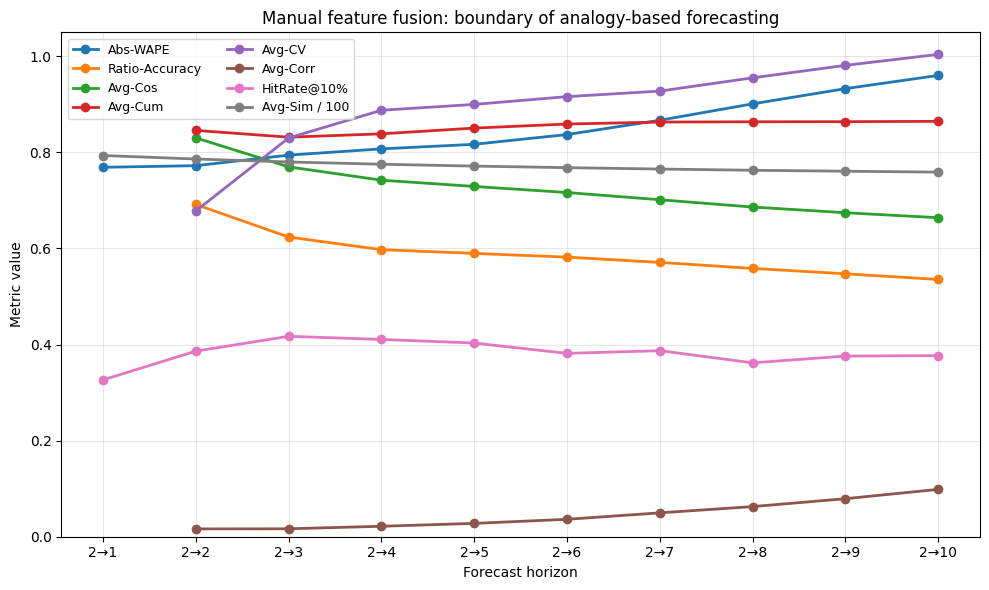

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    {"task": "2→1",  "horizon": 1,  "Abs_WAPE": 0.769039881918455,  "Ratio_Accuracy": None, "Cos": None, "Cum": None, "Avg_CV": None, "Avg_Corr": None, "HitRate@10%": 0.3264733395696913, "Avg_Sim": 79.35875877218724},
    {"task": "2→2",  "horizon": 2,  "Abs_WAPE": 0.772422622793359,  "Ratio_Accuracy": 0.6916935776761441, "Cos": 0.8302894498123191, "Cum": 0.8458467888216569, "Avg_CV": 0.6782059741444085,     "Avg_Corr": 0.0162951342192779, "HitRate@10%": 0.3863423760523854, "Avg_Sim": 78.62814922262605},
    {"task": "2→3",  "horizon": 3,  "Abs_WAPE": 0.7944025924670833, "Ratio_Accuracy": 0.6238442794978372, "Cos": 0.7699773121384913, "Cum": 0.8317273956953172, "Avg_CV": 0.8300934542899938,     "Avg_Corr": 0.0165105821822702, "HitRate@10%": 0.4172123479887745, "Avg_Sim": 78.01573071716139},
    {"task": "2→4",  "horizon": 4,  "Abs_WAPE": 0.8073909354715212, "Ratio_Accuracy": 0.5975743576500754, "Cos": 0.7422239190071084, "Cum": 0.8386994667824297, "Avg_CV": 0.8877843418009135,     "Avg_Corr": 0.0217722865806201, "HitRate@10%": 0.4106641721234799, "Avg_Sim": 77.54089678530613},
    {"task": "2→5",  "horizon": 5,  "Abs_WAPE": 0.8169300746645543, "Ratio_Accuracy": 0.5897688164855472, "Cos": 0.7291928003456400, "Cum": 0.8506674351481157, "Avg_CV": 0.8999740981441328,     "Avg_Corr": 0.0277792607497018, "HitRate@10%": 0.4031805425631431, "Avg_Sim": 77.15426449323817},
    {"task": "2→6",  "horizon": 6,  "Abs_WAPE": 0.8372772928049016, "Ratio_Accuracy": 0.5820369718534888, "Cos": 0.7165295262943605, "Cum": 0.8591004117971924, "Avg_CV": 0.9161340740540350,     "Avg_Corr": 0.0362788906005140, "HitRate@10%": 0.3816651075771749, "Avg_Sim": 76.82795653569491},
    {"task": "2→7",  "horizon": 7,  "Abs_WAPE": 0.8669881666403936, "Ratio_Accuracy": 0.5710794752856172, "Cos": 0.7014691236305105, "Cum": 0.8632270090149704, "Avg_CV": 0.9276852418940827,     "Avg_Corr": 0.0497061894862201, "HitRate@10%": 0.3872778297474275, "Avg_Sim": 76.53905449794355},
    {"task": "2→8",  "horizon": 8,  "Abs_WAPE": 0.9010984664218208, "Ratio_Accuracy": 0.5585509844974570, "Cos": 0.6863181538635602, "Cum": 0.8638042002498321, "Avg_CV": 0.9552901295179156,     "Avg_Corr": 0.0627159303016373, "HitRate@10%": 0.3620205799812909, "Avg_Sim": 76.28873431060620},
    {"task": "2→9",  "horizon": 9,  "Abs_WAPE": 0.9328036323134950, "Ratio_Accuracy": 0.5473233636823005, "Cos": 0.6744585057817788, "Cum": 0.8640120431818910, "Avg_CV": 0.9812662117080546,     "Avg_Corr": 0.0791719261345415, "HitRate@10%": 0.3760523854069224, "Avg_Sim": 76.08701207971527},
    {"task": "2→10", "horizon": 10, "Abs_WAPE": 0.9602881792808698, "Ratio_Accuracy": 0.5355379378689056, "Cos": 0.6641137458734313, "Cum": 0.8647041877776246, "Avg_CV": 1.0041165723340788,     "Avg_Corr": 0.0985851810433353, "HitRate@10%": 0.3769878391019644, "Avg_Sim": 75.89933379499504},
]

df = pd.DataFrame(data)

# Avg_Sim 原始是 0-100，这里转成 0-1
df["Avg_Sim_scaled"] = df["Avg_Sim"] / 100

plt.figure(figsize=(10, 6))

metrics = [
    "Abs_WAPE",
    "Ratio_Accuracy",
    "Cos",
    "Cum",
    "Avg_CV",
    "Avg_Corr",
    "HitRate@10%",
    "Avg_Sim_scaled",
]

labels = {
    "Abs_WAPE": "Abs-WAPE",
    "Ratio_Accuracy": "Ratio-Accuracy",
    "Cos": "Avg-Cos",
    "Cum": "Avg-Cum",
    "Avg_CV": "Avg-CV",
    "Avg_Corr": "Avg-Corr",
    "HitRate@10%": "HitRate@10%",
    "Avg_Sim_scaled": "Avg-Sim / 100",
}

for m in metrics:
    plt.plot(
        df["horizon"],
        df[m],
        marker="o",
        linewidth=2,
        label=labels[m]
    )

plt.xlabel("Forecast horizon")
plt.ylabel("Metric value")
plt.title("Manual feature fusion: boundary of analogy-based forecasting")
plt.xticks(df["horizon"], df["task"])
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Retrieval Features + LightGBM

In [52]:
# 对训练集执行同一套 PS 相似品搜索，得到训练样本对应的相似品聚合曲线和邻居明细
ps = ProductSimilarity(train = train, test = test)
week_since_launch = 2
total_week = 3

train_ref_codes_df, train_ref_curves_df = ps.sim_output(
    df = train,
    week_since_launch = week_since_launch,
    total_week = total_week,
    curve_weight = {'cos': 0.3, 'mag': 0.4, 'cum': 0.3},
    final_weight = {'curve': 0.3, 'image': 0.5, 'attr': 0.2},
    curve_threshold = 70,
    final_threshold = 65,
    cv_threshold = 100,
    top_k = 20,
    show_progress = False
)
print(f"✅ 完成：train_ref_curves_df = {len(train_ref_curves_df)} 行，"
      f"有效相似品样本 = {train_ref_curves_df['ref_curve_mean'].notna().sum()}")

/var/folders/l7/qt___nks3hlfj2mrg3469k_00000gn/T/ipykernel_13421/2331475907.py:203: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(ref_codes_list, ignore_index=True), pd.DataFrame(ref_curves_list)


✅ 完成：train_ref_curves_df = 96166 行，有效相似品样本 = 90304


In [53]:
# 对训练集执行 GS 分组搜索，用于补全 PS 没有 top-k 邻居的产品
gs = GroupSimilarity(train = train, test = test, min_samples = 6)
train_group_curves_df = gs.sim_output(
    df = train,
    week_since_launch = week_since_launch,
    total_week = total_week
)
print(f"✅ 训练集 GS 完成：{len(train_group_curves_df)} 行，"
      f"GS 有效曲线 = {train_group_curves_df['ref_curve_mean'].notna().sum()}")

def fuse_ps_with_gs(ps_curves_df, gs_curves_df):
    """
    对 PS 没拿到 top-k 邻居（ref_curve_mean 为 None）的样本，用 GS 的曲线整套兜底。
    保留 gs_score / gs_group_level 作为下游 LightGBM 的附加特征。
    新增 is_gs_fallback 标志（0=PS 命中，1=GS 回退），便于 LightGBM 区分两类样本。
    """
    gs_cols = ['external_code', 'retail',
               'ref_curve_mean', 'ref_curve_median', 'ref_curve_25', 'ref_curve_75',
               'best_similarity_score', 'best_group_level']
    rename_map = {
        'ref_curve_mean'        : 'gs_ref_curve_mean',
        'ref_curve_median'      : 'gs_ref_curve_median',
        'ref_curve_25'          : 'gs_ref_curve_25',
        'ref_curve_75'          : 'gs_ref_curve_75',
        'best_similarity_score' : 'gs_score',
        'best_group_level'      : 'gs_group_level',
    }
    out = ps_curves_df.merge(
        gs_curves_df[[c for c in gs_cols if c in gs_curves_df.columns]].rename(columns=rename_map),
        on=['external_code', 'retail'], how='left',
    )

    mask = out['ref_curve_mean'].isna()
    out['is_gs_fallback'] = mask.astype(int)

    # 多级兜底：优先用 GS 对应分位数；GS 是旧版（没分位数列）时退回 GS mean，避免 None 残留
    fallback_priority = {
        'ref_curve_mean'  : ['gs_ref_curve_mean'],
        'ref_curve_median': ['gs_ref_curve_median', 'gs_ref_curve_mean'],
        'ref_curve_25'    : ['gs_ref_curve_25',     'gs_ref_curve_mean'],
        'ref_curve_75'    : ['gs_ref_curve_75',     'gs_ref_curve_mean'],
    }
    for tgt, sources in fallback_priority.items():
        for src in sources:
            if src not in out.columns:
                continue
            # 只填 PS 缺失且 tgt 当前仍为空的行
            need = mask & out[tgt].isna()
            if need.any():
                out.loc[need, tgt] = out.loc[need, src]

    # gs_score / gs_group_level 保留给下游模型，只丢用于合并的临时列
    drop_cols = [c for c in ['gs_ref_curve_mean','gs_ref_curve_median','gs_ref_curve_25','gs_ref_curve_75']
                 if c in out.columns]
    return out.drop(columns=drop_cols)

train_ps_gs_curves = fuse_ps_with_gs(train_ref_curves_df, train_group_curves_df)
test_ps_gs_curves  = fuse_ps_with_gs(ref_curves_df,       group_curves_df)

print(f"训练集: PS 有效 {train_ref_curves_df['ref_curve_mean'].notna().sum()} → "
      f"PS+GS 有效 {train_ps_gs_curves['ref_curve_mean'].notna().sum()} / 总 {len(train_ps_gs_curves)} "
      f"（GS 回退 {train_ps_gs_curves['is_gs_fallback'].sum()}）")
print(f"测试集: PS 有效 {ref_curves_df['ref_curve_mean'].notna().sum()} → "
      f"PS+GS 有效 {test_ps_gs_curves['ref_curve_mean'].notna().sum()} / 总 {len(test_ps_gs_curves)} "
      f"（GS 回退 {test_ps_gs_curves['is_gs_fallback'].sum()}）")

策略 cat_color_pri_sea: 436 个有效组
策略 cat_color_sea: 781 个有效组
策略 cat_pri_sea: 344 个有效组
策略 cat_sea: 147 个有效组
策略 cat: 27 个有效组
✅ 训练集 GS 完成：96166 行，GS 有效曲线 = 95275
训练集: PS 有效 90304 → PS+GS 有效 95399 / 总 96166 （GS 回退 5862）
测试集: PS 有效 10237 → PS+GS 有效 10684 / 总 10684 （GS 回退 447）


In [54]:
import numpy as np
import pandas as pd

def build_lgbm_dataset(src_df, ref_codes_df, ref_curves_df, wsl, tw):
    """
    构造 LightGBM 长格式样本（每个 (产品, 周) 为一行）。
    特征 = 目标品自身特征 + 相似品聚合统计特征 + 当周相似品参考曲线分位数
    目标 = 当周实际销量 curve[w]
    """
    df = src_df[[
        'external_code','retail','curve','category','color','fabric','season',
        'price','release_date'
    ]].copy()
    df['release_date'] = pd.to_datetime(df['release_date'])
    df['release_month'] = df['release_date'].dt.month
    df['release_woy']   = df['release_date'].dt.isocalendar().week.astype(int)

    # 已知早期销量统计（前 wsl 周）
    arr = np.array(df['curve'].tolist(), dtype=float)
    if wsl > 0:
        early = arr[:, :wsl]
        df['early_sum']  = early.sum(axis=1)
        df['early_mean'] = early.mean(axis=1)
        df['early_max']  = early.max(axis=1)
        df['early_std']  = early.std(axis=1)
    else:
        df['early_sum'] = df['early_mean'] = df['early_max'] = df['early_std'] = 0.0

    # 相似品 score 统计（来自 ref_codes_df 中真实邻居记录）
    sim_stats = (
        ref_codes_df.dropna(subset=['final_similarity'])
            .groupby(['external_code','retail'])
            .agg(
                n_neighbors    = ('ref_code', 'count'),
                final_sim_mean = ('final_similarity', 'mean'),
                final_sim_max  = ('final_similarity', 'max'),
                final_sim_min  = ('final_similarity', 'min'),
                final_sim_std  = ('final_similarity', 'std'),
                curve_sim_mean = ('curve_similarity', 'mean'),
                attr_sim_mean  = ('attribute_similarity', 'mean'),
                image_sim_mean = ('image_similarity', 'mean'),
            ).reset_index()
    )
    df = df.merge(sim_stats, on=['external_code','retail'], how='left')

    # 邻居一致性元特征：直接复用 test_codes_df，避免重复实现 / 口径不一致
    codes_detail, _ = test_codes_df(ref_codes_df, wsl, tw)
    cons_stats = codes_detail[
        ['external_code', 'retail', 'Avg_pairwise_corr', 'Avg_cv_total', 'Avg_cv_week']
    ].rename(columns={
        'Avg_pairwise_corr': 'nbr_pairwise_corr',
        'Avg_cv_total'     : 'nbr_cv_total',
        'Avg_cv_week'      : 'nbr_cv_week',
    })
    df = df.merge(cons_stats, on=['external_code','retail'], how='left')

    # 相似品聚合曲线 + GS 兜底元信息
    ref_cols = ['external_code','retail',
                'ref_curve_mean','ref_curve_median','ref_curve_25','ref_curve_75',
                'is_gs_fallback','gs_score','gs_group_level']
    df = df.merge(
        ref_curves_df[[c for c in ref_cols if c in ref_curves_df.columns]],
        on=['external_code','retail'], how='left'
    )
    df = df[df['ref_curve_mean'].notna()].reset_index(drop=True)
    # 残余兜底：分位数若仍为 None（上游 GS 旧版未提供分位数），用 mean 兜底，避免 np.array(None) 崩
    for col in ['ref_curve_median', 'ref_curve_25', 'ref_curve_75']:
        if col not in df.columns:
            df[col] = df['ref_curve_mean']
        else:
            miss = df[col].isna()
            if miss.any():
                df.loc[miss, col] = df.loc[miss, 'ref_curve_mean']
    if 'is_gs_fallback' not in df.columns:
        df['is_gs_fallback'] = 0
    else:
        df['is_gs_fallback'] = df['is_gs_fallback'].fillna(0).astype(int)
    # gs_score / gs_group_level 在 PS 命中样本上为 NaN，下游 LGBM 会把 NaN 当 missing 处理
    if 'gs_score' not in df.columns:
        df['gs_score'] = np.nan
    if 'gs_group_level' not in df.columns:
        df['gs_group_level'] = np.nan

    # 展开为长格式：每行 = (产品, week_idx)
    weeks = np.arange(wsl, tw)
    n_weeks = len(weeks)
    static_cols = [
        'external_code','retail','category','color','fabric','season',
        'price','release_month','release_woy',
        'early_sum','early_mean','early_max','early_std',
        'n_neighbors','final_sim_mean','final_sim_max','final_sim_min','final_sim_std',
        'curve_sim_mean','attr_sim_mean','image_sim_mean',
        'nbr_pairwise_corr','nbr_cv_total','nbr_cv_week',
        'is_gs_fallback','gs_score','gs_group_level',
    ]
    rep = df[static_cols].loc[df.index.repeat(n_weeks)].reset_index(drop=True)
    rep['week_idx'] = np.tile(weeks, len(df))

    rep['ref_mean_w'] = np.concatenate([np.array(c)[wsl:tw] for c in df['ref_curve_mean']])
    rep['ref_med_w']  = np.concatenate([np.array(c)[wsl:tw] for c in df['ref_curve_median']])
    rep['ref_25_w']   = np.concatenate([np.array(c)[wsl:tw] for c in df['ref_curve_25']])
    rep['ref_75_w']   = np.concatenate([np.array(c)[wsl:tw] for c in df['ref_curve_75']])
    rep['target']     = np.concatenate([np.array(c)[wsl:tw] for c in df['curve']])
    return rep

train_long = build_lgbm_dataset(train, train_ref_codes_df, train_ps_gs_curves, week_since_launch, total_week)
test_long  = build_lgbm_dataset(test,  ref_codes_df,       test_ps_gs_curves,  week_since_launch, total_week)
print(f"训练样本: {train_long.shape}, 测试样本: {test_long.shape}")
train_long.head(3)

/opt/anaconda3/envs/visuelle_ds/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/visuelle_ds/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/visuelle_ds/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/visuelle_ds/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/visuelle_ds/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/visuelle_ds/lib/python3.10/site-packages/numpy/lib/_

训练样本: (95399, 33), 测试样本: (10684, 33)


,external_code,retail,category,color,fabric,season,price,release_month,release_woy,early_sum,...,nbr_cv_week,is_gs_fallback,gs_score,gs_group_level,week_idx,ref_mean_w,ref_med_w,ref_25_w,ref_75_w,target
0,53,24,long sleeve,black,fur,SS17,0.109910,12,51,5.0,...,NaN,1,90.7,cat_sea,2,1.243869,1.243869,1.243869,1.243869,1.0
1,55,18,culottes,grey,scuba crepe,SS17,0.043951,12,51,3.0,...,NaN,0,NaN,None,2,1.000000,1.000000,1.000000,1.000000,4.0
2,53,19,long sleeve,black,fur,SS17,0.109910,12,51,10.0,...,NaN,1,93.2,cat_sea,2,1.243869,1.243869,1.243869,1.243869,1.0


In [55]:
import lightgbm as lgb

cat_cols = ['category', 'color', 'fabric', 'season', 'gs_group_level']
for c in cat_cols:
    train_long[c] = train_long[c].astype('category')
    test_long[c]  = pd.Categorical(test_long[c], categories=train_long[c].cat.categories)

drop_cols = ['external_code', 'retail', 'target']
feature_cols = [c for c in train_long.columns if c not in drop_cols]

X_train, y_train = train_long[feature_cols], train_long['target']
X_test,  y_test  = test_long[feature_cols],  test_long['target']

# 从训练集按产品分组切出 validation 用于 early stopping，避免用测试集
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, va_idx = next(gss.split(X_train, groups=train_long['external_code']))
X_tr, y_tr = X_train.iloc[tr_idx].copy(), y_train.iloc[tr_idx]
X_va, y_va = X_train.iloc[va_idx].copy(), y_train.iloc[va_idx]
for c in cat_cols:
    X_va[c] = pd.Categorical(X_va[c], categories=X_tr[c].cat.categories)
print(f"训练: {len(X_tr)}  验证: {len(X_va)}  测试: {len(X_test)}")

lgbm_params = dict(
    n_estimators       = 2000,
    learning_rate      = 0.05,
    num_leaves         = 31,
    min_child_samples  = 20,
    feature_fraction   = 0.9,
    bagging_fraction   = 0.9,
    bagging_freq       = 5,
    objective          = 'regression_l1',
    random_state       = 42,
    verbose            = -1,
)
early_stopping_rounds = 100
val_size              = 0.15

model = lgb.LGBMRegressor(**lgbm_params)
model.fit(
    X_tr, y_tr,
    categorical_feature = cat_cols,
    eval_set            = [(X_va, y_va)],
    callbacks           = [lgb.early_stopping(early_stopping_rounds), lgb.log_evaluation(0)]
)

imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
print("Top-15 重要特征：")
print(imp_df.head(15))

训练: 80422  验证: 14977  测试: 10684
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[68]	valid_0's l1: 0.998111
Top-15 重要特征：
           feature  importance
0           fabric         448
1         category         344
2      release_woy         274
3        early_sum         130
4    final_sim_max         112
5    final_sim_std          81
6            color          73
7    release_month          61
8           season          61
9        early_max          61
10           price          52
11  image_sim_mean          50
12   attr_sim_mean          46
13        gs_score          43
14  final_sim_mean          31


In [68]:
# 预测每周销量并拼回为完整 12 周曲线
test_long['pred'] = np.maximum(0.0, model.predict(X_test))
pred_pivot = test_long.pivot_table(
    index   = ['external_code', 'retail'],
    columns = 'week_idx',
    values  = 'pred'
)

def assemble_pred_curve(src_df, pred_pivot, wsl, tw):
    """
    把 LightGBM 的逐周预测拼回为完整曲线（前 wsl 周保留真实值，后续用预测值），
    输出格式与 ref_curves_df 兼容，可直接喂给 test_curves_df。
    """
    out = src_df[['external_code', 'retail', 'curve']].copy()
    pred_dict = pred_pivot.to_dict('index')

    def fill(row):
        key = (row['external_code'], row['retail'])
        if key not in pred_dict:
            return None
        full = list(row['curve'])
        preds = pred_dict[key]
        for w in range(wsl, tw):
            v = preds.get(w, np.nan)
            if pd.notna(v):
                full[w] = float(v)
        return full

    out['ref_curve_mean'] = out.apply(fill, axis=1)
    return out

lgbm_pred_df = assemble_pred_curve(test, pred_pivot, week_since_launch, total_week)

print("=== LightGBM with Neighbor Features ===")
lgbm_summary, lgbm_global_wape, lgbm_coverage = test_curves_df(
    df = lgbm_pred_df, wsl = week_since_launch, tw = total_week
)

# 记录到实验日志（参数 = LGBM 超参 + PS/GS 召回参数 + 训练规模 / best_iteration）
lgbm_full_params = {
    **{f'lgbm.{k}': v for k, v in lgbm_params.items()},
    'lgbm.early_stopping_rounds': early_stopping_rounds,
    'lgbm.val_size'             : val_size,
    'lgbm.best_iteration'       : int(getattr(model, 'best_iteration_', model.n_estimators) or model.n_estimators),
    'lgbm.n_features'           : len(feature_cols),
    'lgbm.n_train_samples'      : int(len(X_tr)),
    'lgbm.n_val_samples'        : int(len(X_va)),
    'lgbm.n_test_samples'       : int(len(X_test)),
    **{f'ps.{k}': v for k, v in ps_params.items()},
    **{f'gs.{k}': v for k, v in gs_params.items()},
}

log_experiment(
    log_path     = LOG_PATH,
    model_name   = 'LGBM_with_Neighbor_Features',
    params       = lgbm_full_params,
    summary_stats= lgbm_summary,
    global_wape  = lgbm_global_wape,
    coverage     = lgbm_coverage,
    codes_summary= None,
    note         = None,
)

=== LightGBM with Neighbor Features ===
有效样本占比: 100.0000%
全局汇总 WAPE: 0.7161
爆款捕捉率（前 10%，共 1069/10684 个产品）: 0.3873
单个产品预测精确度的简单平均：
✅ 已记录到 experiment_log.csv (累计 8 次实验)


,timestamp,model,note,wsl,tw,lgbm.n_estimators,lgbm.learning_rate,lgbm.num_leaves,lgbm.min_child_samples,lgbm.feature_fraction,...,Pearson_i_mean,Pearson_i_median,Pearson_i_std,DTW_i_mean,DTW_i_median,DTW_i_std,Global_WAPE_mean,Hit_Capture_Rate@top10%_mean,Global_WAPE,Coverage
0,2026-05-11 10:28:28,LGBM_with_Neighbor_Features,NaN,2,3,2000,0.05,31,20,0.9,...,0.791135,0.923381,0.326122,0.970396,1.000000,1.163738,0.175329,0.867166,0.175329,1.0
1,2026-05-11 10:28:31,LGBM_basic,仅产品自身属性 + 前 wsl 周销量统计；无相似品/邻居特征,2,3,2000,0.05,31,20,0.9,...,0.000000,0.000000,0.000000,0.976904,0.996016,1.152175,0.720854,0.368569,0.720854,1.0
2,2026-05-11 10:52:55,LGBM_with_Neighbor_Features,NaN,2,3,2000,0.05,31,20,0.9,...,0.000000,0.000000,0.000000,0.970396,1.000000,1.163738,0.716051,0.387278,0.716051,1.0
3,2026-05-11 10:54:25,LGBM_with_Neighbor_Features,NaN,2,3,2000,0.05,31,20,0.9,...,0.791135,0.923381,0.326122,0.970396,1.000000,1.163738,0.175329,0.867166,0.175329,1.0
4,2026-05-11 10:54:34,LGBM_with_Neighbor_Features,NaN,2,3,2000,0.05,31,20,0.9,...,0.668087,0.880093,0.470093,0.970396,1.000000,1.163738,0.237797,0.790458,0.237797,1.0
5,2026-05-11 10:54:45,LGBM_with_Neighbor_Features,NaN,2,3,2000,0.05,31,20,0.9,...,0.891215,0.944742,0.159739,0.970396,1.000000,1.163738,0.118481,0.911132,0.118481,1.0
6,2026-05-11 10:54:55,LGBM_with_Neighbor_Features,NaN,2,3,2000,0.05,31,20,0.9,...,0.941947,0.966375,0.076449,0.978071,1.000000,1.168032,0.086705,0.936389,0.086705,1.0
7,2026-05-11 10:55:16,LGBM_with_Neighbor_Features,None,2,3,2000,0.05,31,20,0.9,...,0.000000,0.000000,0.000000,0.970396,1.000000,1.163738,0.716051,0.387278,0.716051,1.0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import lightgbm as lgb

# ==================== 早期销量特征 ====================
wsl = week_since_launch  # 前 wsl 周
tw  = total_week         # 总周数

def add_early_sales_features(df, wsl):
    df = df.copy()
    arr = np.array(df['curve'].tolist(), dtype=float)
    df['early_sum']  = arr[:, :wsl].sum(axis=1)
    df['early_mean'] = arr[:, :wsl].mean(axis=1)
    df['early_max']  = arr[:, :wsl].max(axis=1)
    df['early_std']  = arr[:, :wsl].std(axis=1)
    return df

train_f = add_early_sales_features(train, wsl)
test_f  = add_early_sales_features(test,  wsl)

# ==================== onehot 属性（train + test 合并编码，保证列对齐） ====================
num_cols = ['early_sum','early_mean','early_max','early_std']
cat_cols = ['category','color','fabric','season']

all_attrs = pd.concat(
    [train_f[num_cols + cat_cols].reset_index(drop=True),
     test_f [num_cols + cat_cols].reset_index(drop=True)],
    ignore_index=True,
)
all_dummies = pd.get_dummies(all_attrs, columns=cat_cols, drop_first=False).astype(float)
n_train = len(train_f)
X_attr_train = all_dummies.iloc[:n_train].values
X_attr_test  = all_dummies.iloc[n_train:].values

# 图片向量
image_emb_train = np.stack(train_f['image_emb'].values)
image_emb_test  = np.stack(test_f ['image_emb'].values)

# 属性 onehot + 图片向量
X_train_static = np.hstack([X_attr_train, image_emb_train])
X_test_static  = np.hstack([X_attr_test,  image_emb_test])
print(f"静态特征维度: train={X_train_static.shape}, test={X_test_static.shape}")

# ==================== 展开成长格式：每行 = (产品, week_idx) ====================
y_train_full = np.array(train_f['curve'].tolist(), dtype=float)
y_test_full  = np.array(test_f ['curve'].tolist(), dtype=float)
n_weeks = tw - wsl

def to_long(X_static, y_full, wsl, tw):
    """把 (n, d_static) + (n, T) 展开成 ((n*n_weeks, d_static+1), (n*n_weeks,))，最后一列是 week_idx"""
    n = X_static.shape[0]
    rep_X     = np.repeat(X_static, tw - wsl, axis=0)
    week_col  = np.tile(np.arange(wsl, tw), n).reshape(-1, 1)
    X_long    = np.hstack([rep_X, week_col])
    y_long    = y_full[:, wsl:tw].reshape(-1)
    return X_long, y_long

X_train_long, y_train_long = to_long(X_train_static, y_train_full, wsl, tw)
X_test_long,  y_test_long  = to_long(X_test_static,  y_test_full,  wsl, tw)
print(f"长格式: train={X_train_long.shape}, test={X_test_long.shape}")

# ==================== 按 external_code 分组切验证集（防泄露 early stopping） ====================
groups_long = np.repeat(train_f['external_code'].values, n_weeks)
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, va_idx = next(gss.split(X_train_long, y_train_long, groups=groups_long))
X_tr, y_tr = X_train_long[tr_idx], y_train_long[tr_idx]
X_va, y_va = X_train_long[va_idx], y_train_long[va_idx]
print(f"训练: {len(X_tr)}  验证: {len(X_va)}  测试: {len(X_test_long)}")

# ==================== LGBM 训练 ====================
lgbm_img_params = dict(
    n_estimators      = 2000,
    learning_rate     = 0.05,
    num_leaves        = 31,
    min_child_samples = 20,
    feature_fraction  = 0.9,
    bagging_fraction  = 0.9,
    bagging_freq      = 5,
    objective         = 'regression_l1',
    random_state      = 42,
    verbose           = -1,
)
early_stopping_rounds_img = 100
val_size_img              = 0.15

img_model = lgb.LGBMRegressor(**lgbm_img_params)
img_model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(early_stopping_rounds_img), lgb.log_evaluation(0)],
)

# ==================== 预测 + 拼回完整曲线 ====================
y_pred_long = np.maximum(0.0, img_model.predict(X_test_long))
pred_curve  = y_pred_long.reshape(len(test_f), n_weeks)

img_pred_df = test_f[['external_code','retail','curve']].copy().reset_index(drop=True)
def _fill(row_curve, pred_row):
    full = list(row_curve)
    full[wsl:tw] = list(pred_row)
    return full
img_pred_df['ref_curve_mean'] = [
    _fill(c, p) for c, p in zip(img_pred_df['curve'], pred_curve)
]

print("=== LightGBM (image embedding + onehot attrs + early sales) ===")
img_summary, img_global_wape, img_coverage = test_curves_df(
    df = img_pred_df, wsl = wsl, tw = tw,
)

# ==================== 入表 ====================
img_full_params = {
    **{f'lgbm.{k}': v for k, v in lgbm_img_params.items()},
    'lgbm.early_stopping_rounds': early_stopping_rounds_img,
    'lgbm.val_size'             : val_size_img,
    'lgbm.best_iteration'       : int(getattr(img_model, 'best_iteration_', img_model.n_estimators) or img_model.n_estimators),
    'lgbm.n_features'           : X_train_long.shape[1],
    'lgbm.n_train_samples'      : int(len(X_tr)),
    'lgbm.n_val_samples'        : int(len(X_va)),
    'lgbm.n_test_samples'       : int(len(X_test_long)),
    'feat.image_emb_dim'        : image_emb_train.shape[1],
    'feat.attr_onehot_dim'      : X_attr_train.shape[1] - len(num_cols),
    'feat.use_week_idx'         : True,
}

log_experiment(
    log_path     = LOG_PATH,
    model_name   = 'LGBM_attr_image_early',
    params       = img_full_params,
    summary_stats= img_summary,
    global_wape  = img_global_wape,
    coverage     = img_coverage,
    codes_summary= None,
    note         = '属性 onehot + 图片向量 + 早期销量；无相似品/邻居特征',
)